# IGRF library testing

Comparing my C implementation of igrf to the python IGRF library, to make sure they produce similar results.

In [1]:
import ctypes
import numpy as np
from datetime import datetime
from orbital_elements import OrbitalElements
from igrf import cartesian_to_lat_long, mag_from_pos as python_igrf

In [2]:


lib = ctypes.CDLL("./secrets/igrf.so")  # not public

# Define the IGRF time structure
class IGRFTime(ctypes.Structure):
    _fields_ = [
        ("year", ctypes.c_uint16),
        ("month", ctypes.c_uint8),
        ("day", ctypes.c_uint8),
        ("hour", ctypes.c_uint8),
        ("minute", ctypes.c_uint8),
        ("second", ctypes.c_uint8),
    ]


# IGRF frame value
IGRF_GEODETIC = 0
IGRF_GEOCENTRIC = 1

lib.igrf.argtypes = (
    IGRFTime,
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_int,
    ctypes.POINTER(ctypes.c_double),
)
lib.igrf.restype = ctypes.c_int

In [3]:
# set up the c_igrf function

def c_igrf(x, time):
  lat, long, alt_km = cartesian_to_lat_long(x)
  radius = alt_km + 6371.2

  x = (ctypes.c_double * 3)(lat, long, radius)
  b = (ctypes.c_double * 3)()

  lib.igrf(time, x, 1, b)

  res = np.array([0, 0, 0])

  for i in range(3):
    res[i] = b[i]
  
  return res


In [4]:
# Make orbit and prepare values 
orbital_elements = OrbitalElements(6978000, 0, 0, 56 * np.pi / 180, 0, 0)

h = 100
t_final = 5400
steps = int(t_final / 100)

tout = np.linspace(0, t_final, steps)
mag_python = np.zeros((steps, 3))
mag_c = np.zeros((steps, 3))

In [5]:
# Evaluate the model at the same time in c and python
c_time = IGRFTime(2025, 1, 1, 0, 0, 0)
python_time = datetime(2025, 1, 1)

for i, t in enumerate(tout):
  x, _ = orbital_elements.evaluate(t)

  mag_python[i] = python_igrf(x, python_time)
  mag_c[i] = c_igrf(x, c_time)

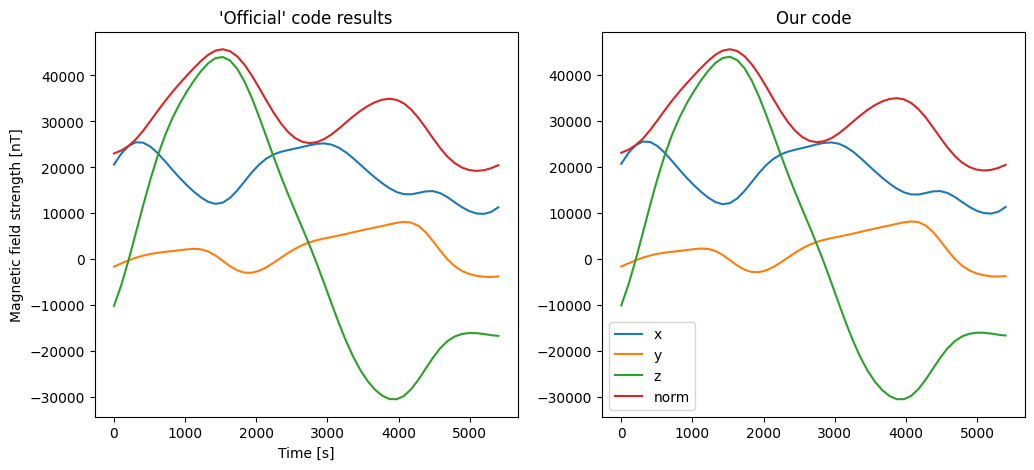

In [10]:
import matplotlib.pyplot as plt


fig, axs = plt.subplots(1, 2, figsize=(12, 5))
ax1, ax2 = axs[0:2]

mag_python_norm = [np.linalg.norm(v) for v in mag_python]
ax1.plot(tout, mag_python[:, 0], label="x")
ax1.plot(tout, mag_python[:, 1], label="y")
ax1.plot(tout, mag_python[:, 2], label="z")
ax1.plot(tout, mag_python_norm, label="norm")
ax1.set_ylabel("Magnetic field strength [nT]")
ax1.set_xlabel("Time [s]")
ax1.set_title("'Official' code results")

mag_c_norm = [np.linalg.norm(v) for v in mag_c]
ax2.plot(tout, mag_c[:, 0], label="x")
ax2.plot(tout, mag_c[:, 1], label="y")
ax2.plot(tout, mag_c[:, 2], label="z")
ax2.plot(tout, mag_c_norm, label="norm")
ax2.set_title("Our code")

plt.legend()
plt.show()

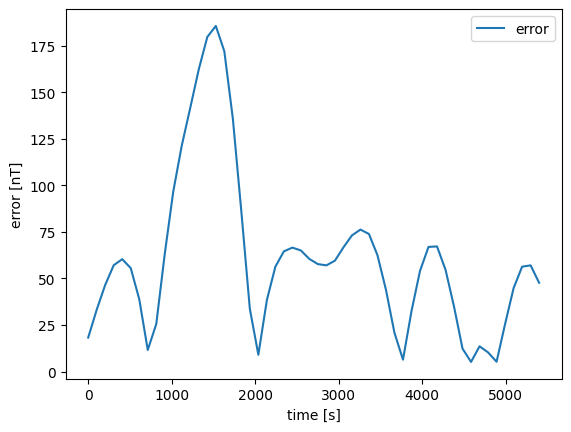

In [41]:
diff = []
for i in range(len(tout)):
  diff.append(np.abs(mag_python_norm[i] - mag_c_norm[i]))

fig = plt.figure()

plt.plot(tout, diff, label="error")

plt.xlabel("time [s]")
plt.ylabel("error [nT]")
plt.title("Absolute error between python and matlab IGRF models")
plt.legend()
plt.show()